# The TW Project

## Stage 1: Finetune a YOLO26s on LLVIP dataset

### Data preparation

In [ ]:
"""Download the LLVIP dataset"""

import os

LLVIP_DATASET_URL = "https://drive.google.com/uc?id=1VTlT3Y7e1h-Zsne4zahjx5q0TK2ClMVv"

def download_llvip_dataset():
    import gdown
    gdown.download(
        url=LLVIP_DATASET_URL,
        output="LLVIP.zip",
    )

if not os.path.exists("LLVIP.zip"):
    print("Dataset not downloaded, now downloading")
    download_llvip_dataset()
else:
    import hashlib

    with open("LLVIP.zip", "rb") as f:
        file_hash = hashlib.md5()
        while chunk := f.read(8192):
            file_hash.update(chunk)
    if file_hash.hexdigest() != "e64affb4b0b50e1772ff6f67da873bf6":
        print("Download dataset again due to hash mismatch")
        download_llvip_dataset()

if not os.path.exists("datasets"):
    os.makedirs("datasets")

if not os.path.exists("datasets/LLVIP"):
    import zipfile
    
    with zipfile.ZipFile("LLVIP.zip", "r") as zip_ref:
        zip_ref.extractall("datasets")

In [ ]:
"""Convert VOC format to YOLO format."""
import shutil
import globox as gx
from pathlib import Path

LLVIP_DATASET_PATH = Path("datasets/LLVIP").resolve()

IMG_DIR = LLVIP_DATASET_PATH / "infrared"
LABELS_DIR = LLVIP_DATASET_PATH / "labels"

TRAIN_SPLIT_PATH = IMG_DIR / "train"
VAL_SPLIT_PATH = IMG_DIR / "test"
TRAIN_LABELS_DIR = LABELS_DIR / "train"
VAL_LABELS_DIR = LABELS_DIR / "test"

TRAIN_LABELS_DIR.mkdir(exist_ok=True)
VAL_LABELS_DIR.mkdir(exist_ok=True)

llvip = gx.AnnotationSet.from_pascal_voc(LLVIP_DATASET_PATH / "Annotations")
llvip.show_stats()
llvip.save_yolo_v7(
    save_dir=LABELS_DIR,
    label_to_id={"person": 0},
)

for split_img_dir, labels_out_dir in [
    (TRAIN_SPLIT_PATH, TRAIN_LABELS_DIR),
    (VAL_SPLIT_PATH, VAL_LABELS_DIR),
]:
    for img_path in split_img_dir.iterdir():
        label_file = LABELS_DIR / f"{img_path.stem}.txt"
        if label_file.exists():
            shutil.move(str(label_file), labels_out_dir / label_file.name)
        else:
            print(f"WARNING: no label for {img_path.name}")

yaml_path = LLVIP_DATASET_PATH / "llvip.yaml"
yaml_path.write_text(f"""train: {TRAIN_SPLIT_PATH}
val: {VAL_SPLIT_PATH}
nc: 1
names: ['person']
""")

          Database Stats          
┏━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┓
┃ Label         ┃ Images ┃ Boxes ┃
┡━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━┩
│ <empty_image> │      2 │     0 │
│ person        │  15486 │ 42437 │
├───────────────┼────────┼───────┤
│ Total         │  15488 │ 42437 │
└───────────────┴────────┴───────┘

133

### Tuning and training

In [ ]:
from pathlib import Path
from ultralytics.models.yolo.detect import DetectionTrainer


class CustomSaveTrainer(DetectionTrainer):
    """Trainer that saves the best model based on recall instead of default fitness."""

    def validate(self):
        """Override fitness to use recall for best model selection."""
        metrics, fitness = super().validate()
        if metrics:
            recall  = metrics.get("metrics/recall(B)", 0.0)
            map50   = metrics.get("metrics/mAP50(B)", 0.0)
            map5095 = metrics.get("metrics/mAP50-95(B)", 0.0)

            fitness = (0.60 * recall) + (0.30 * map5095) + (0.10 * map50)

            if self.best_fitness is None or fitness > self.best_fitness:
                self.best_fitness = fitness
        return metrics, fitness

In [ ]:
"""Train YOLO26n"""

from ultralytics import YOLO


yaml_path = Path("datasets/LLVIP/llvip.yaml").resolve()

model = YOLO("yolo26n.pt")
model.train(
    data=yaml_path,
    epochs=50,
    imgsz=640,
    batch=64,
    optimizer="MuSGD",
    lr0=0.0054,
    lrf=0.0495,
    momentum=0.947,
    weight_decay=0.00064,
    warmup_epochs=0.98,
    name="llvip_yolo26n",
    cache='disk',
    patience=20,
    trainer=CustomSaveTrainer,
    exist_ok=True,
    device="cuda:0",
    workers=16,
    close_mosaic=15,
    # Augmentation
    hsv_h=0.0,
    hsv_s=0.0,
    hsv_v=0.2,
    degrees=0.0,
    translate=0.1,
    scale=0.4,
    shear=0.0,
    flipud=0.0,
    fliplr=0.5,
    mosaic=0.2,
    mixup=0.0,
    erasing=0.2,
)

New https://pypi.org/project/ultralytics/8.4.51 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.46 🚀 Python-3.13.13 torch-2.12.0+rocm7.2 CUDA:1 (AMD Radeon Graphics, 16368MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=64, bgr=0.0, box=7.5, cache=disk, cfg=None, classes=None, close_mosaic=15, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/home/w/tw_project/datasets/LLVIP/llvip.yaml, degrees=0.0, deterministic=True, device=1, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.2, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.0, hsv_s=0.0, hsv_v=0.2, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0054, lrf=0.0495, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.947, mosaic=0.2

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7f29d456c210>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

### Model export and inference

In [ ]:
from ultralytics import YOLO
from pathlib import Path

model = YOLO("runs/detect/llvip_yolo26n/weights/best.pt")
model.export(
    format="onnx",
    imgsz=640,
    name="llvip_yolo26n"
)

Ultralytics 8.4.46 🚀 Python-3.13.13 torch-2.12.0+rocm7.2 CPU (AMD Ryzen 5 5600G with Radeon Graphics)
YOLO26n summary (fused): 122 layers, 2,375,031 parameters, 0 gradients, 5.2 GFLOPs

PyTorch: starting from 'runs/detect/llvip_yolo26n_rc_2/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 300, 6) (5.1 MB)
requirements: Ultralytics requirement ['onnxruntime-gpu'] not found, attempting AutoUpdate...
Resolved 5 packages in 400ms
Prepared 1 package in 17.27s
         If the cache and target directories are on different filesystems, hardlinking may not be supported.
         If this is intentional, set `export UV_LINK_MODE=copy` or use `--link-mode=copy` to suppress this warning.
Installed 1 package in 333ms
 + onnxruntime-gpu==1.26.0

requirements: AutoUpdate success ✅ 18.1s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.21.0 opset 20...
ONNX: slimming with onnxslim 0.1.93...


/home/w/tw_project/.venv/lib/python3.13/site-packages/torch/onnx/_internal/torchscript_exporter/symbolic_opset11.py:954: UserWarning: Exporting aten::index operator of advanced indexing in opset 20 is achieved by combination of multiple ONNX operators, including Reshape, Transpose, Concat, and Gather. If indices include negative values, the exported graph will produce incorrect results.
  return opset9.index(g, self, index)


ONNX: export success ✅ 19.0s, saved as 'runs/detect/llvip_yolo26n_rc_2/weights/best.onnx' (9.4 MB)

Export complete (19.4s)
Results saved to /home/w/tw_project/runs/detect/llvip_yolo26n_rc_2/weights/best.onnx
Predict:         yolo predict task=detect model=runs/detect/llvip_yolo26n_rc_2/weights/best.onnx imgsz=640 
Validate:        yolo val task=detect model=runs/detect/llvip_yolo26n_rc_2/weights/best.onnx imgsz=640 data=/home/w/tw_project/datasets/LLVIP/llvip.yaml  
Visualize:       https://netron.app


'runs/detect/llvip_yolo26n_rc_2/weights/best.onnx'

In [ ]:
"""Run val"""

from ultralytics import YOLO
from pathlib import Path

# model = YOLO("runs/detect/llvip_yolo26n/weights/best.onnx")
model = YOLO("runs/detect/llvip_yolo26n/weights/best.pt")
metrics = model.val(
    data=Path("datasets/LLVIP/llvip.yaml").resolve(),
    name="llvip_val_results",
    batch=512,
    imgsz=640,
    # device="cpu",
    device="cuda:0",
    exist_ok=True,
    save_json=True,
)

(null): No such file or directory
(null): No such file or directory


Ultralytics 8.4.46 🚀 Python-3.13.13 torch-2.12.0+rocm7.2 CPU (AMD Ryzen 5 5600G with Radeon Graphics)
Loading runs/detect/llvip_yolo26n_rc_2/weights/best.onnx for ONNX Runtime inference...
Using ONNX Runtime 1.26.0 with CPUExecutionProvider
Setting batch=1 input of shape (1, 3, 640, 640)
val: Fast image access ✅ (ping: 0.4±0.2 ms, read: 262.9±88.8 MB/s, size: 89.6 KB)


(null): No such file or directory
(null): No such file or directory


val: Scanning /home/w/tw_project/datasets/LLVIP/labels/val.cache... 3463 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 3463/3463 854.4Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3463/3463 28.4it/s 2:02<0.0ss
                   all       3463       8302      0.968      0.894      0.958      0.638
Speed: 6.5ms preprocess, 21.2ms inference, 0.0ms loss, 0.1ms postprocess per image
Saving /home/w/tw_project/runs/detect/llvip_val_results/predictions.json...
Results saved to /home/w/tw_project/runs/detect/llvip_val_results


## Stage 2: LLM

### Annotate images

In [ ]:
"""Test with one image"""

import json
import glob
import os
from pathlib import Path
from PIL import Image, ImageDraw, ImageFont
from IPython.display import display


PREDICTIONS_PATH = Path("runs/detect/llvip_val_results/predictions.json").resolve()
IMG_SRC_DIR      = Path("datasets/LLVIP/images/val").resolve()
IMG_OUT_DIR      = Path("datasets/LLVIP/annotated_new").resolve()

THRESHOLD        = 0.2
CATEGORY_NAMES   = {1: "person"}
CROP_PADDING     = 40  # pixels

os.makedirs(IMG_OUT_DIR, exist_ok=True)

def load_yolo_predictions(path, threshold):
    with open(path) as f:
        preds = json.load(f)
    grouped = {}
    for p in preds:
        if p["score"] >= threshold:
            grouped.setdefault(p["file_name"], []).append(p)
    return grouped

def annotate_image(img_path, boxes):
    stem = Path(img_path).stem
    os.makedirs(IMG_OUT_DIR / stem, exist_ok=True)

    img = Image.open(img_path).convert("RGB")

    # Save original as 0.jpg
    img.save(IMG_OUT_DIR / stem / "0.jpg")

    font  = ImageFont.load_default(20)
    lines = []

    for i, box in enumerate(boxes, start=1):
        x, y, w, h      = box["bbox"]
        x1, y1, x2, y2  = x, y, x + w, y + h
        score            = box["score"]
        category         = CATEGORY_NAMES.get(box["category_id"], "unknown")

        # Crop with padding, clamped to image bounds
        iw, ih = img.size
        cx1 = max(0,  x1 - CROP_PADDING)
        cy1 = max(0,  y1 - CROP_PADDING)
        cx2 = min(iw, x2 + CROP_PADDING)
        cy2 = min(ih, y2 + CROP_PADDING)

        crop = img.crop((cx1, cy1, cx2, cy2)).copy()
        draw = ImageDraw.Draw(crop)

        # Box coords relative to crop origin
        rx1, ry1 = x1 - cx1, y1 - cy1
        rx2, ry2 = x2 - cx1, y2 - cy1

        draw.rectangle([rx1, ry1, rx2, ry2], outline="red", width=2)

        label = f"#{i}, {score:.2f}"
        tb = draw.textbbox((rx1, ry1 - 18), label, font=font)
        draw.rectangle([tb[0] - 2, tb[1] - 2, tb[2] + 2, tb[3] + 2], fill="red")
        draw.text((rx1, ry1 - 18), label, fill="white", font=font)

        crop.save(IMG_OUT_DIR / stem / f"{i}.jpg")
        lines.append(f"Box #{i}: category={category}, confidence={score:.5f}")

        # print(IMG_OUT_DIR / stem / f"{i}.jpg")
        # display(crop)

    with open(IMG_OUT_DIR / stem / f"{stem}.txt", "w") as f:
        f.write("\n".join(lines) + ("\n" if lines else ""))

if __name__ == "__main__":
    predictions = load_yolo_predictions(PREDICTIONS_PATH, THRESHOLD)
    img_files   = sorted(glob.glob(os.path.join(IMG_SRC_DIR, "*.jpg")))

    if img_files:
        TEST_IDX = 8
        img_path = img_files[TEST_IDX]
        fname = os.path.basename(img_path)
        boxes = predictions.get(fname, [])
        annotate_image(img_path, boxes)

In [ ]:
"""Batch process"""

if __name__ == "__main__":
    predictions = load_yolo_predictions(PREDICTIONS_PATH, THRESHOLD)
    img_files   = sorted(glob.glob(os.path.join(IMG_SRC_DIR, "*.jpg")))

    if img_files:
        n_with_boxes = 0
        for img_path in tqdm(img_files, desc="Annotating"):
            fname = os.path.basename(img_path)
            boxes = predictions.get(fname, [])
            annotate_image(img_path, boxes)
            n_with_boxes += bool(boxes)

Annotating:   0%|          | 0/3463 [00:00<?, ?it/s]

### LLM prompting

In [1]:
"""Test single response"""

import litellm
import asyncio
import base64
import os
from pathlib import Path
from pydantic import BaseModel
from typing import Any, Literal

os.environ["OPENAI_API_KEY"] = "sk-lmao"

PREDICTIONS_PATH = Path("runs/detect/llvip_val_results/predictions.json").resolve()
IMG_SRC_DIR      = Path("datasets/LLVIP/images/val").resolve()
IMG_OUT_DIR      = Path("datasets/LLVIP/annotated_new").resolve()

SYSTEM_PROMPT = """You are a quality-control assistant for an infrared (thermal) pedestrian detector.

You will receive:
1. An infrared image of a scene without any annotations.
2. Cropped infrared images of each detected box, with a red bounding box drawn on it.
3. A metadata block listing each box's number, category label, and detector confidence score.

Your task is to inspect each box individually and decide whether it is a valid detection.

Rules:
- The images are low-resolution infrared: humans appear as bright (hot) blobs against a darker background.
- A VALID box tightly encloses a human body or a clear portion of one (head, torso, legs).
- A FALSE_POSITIVE box covers background clutter, vehicle heat signatures, reflections, artifacts,
  or a region with no discernible human shape.
- Use UNCERTAIN when image quality or occlusion makes a confident call difficult in a short time.

DO NOT skip any boxes present in the metadata. The number of boxes in the output MUST match the number of boxes in the metadata.
LATENCY SENSITIVE. THINK QUICKLY.
"""

class BoxVerdict(BaseModel):
    id: int
    verdict: Literal["VALID", "FALSE_POSITIVE", "UNCERTAIN"]

class BoxesList(BaseModel):
    boxes: list[BoxVerdict]


def _encode_image_b64(path: Path) -> str:
    """Blocking — always call via run_in_executor."""
    return base64.b64encode(path.read_bytes()).decode()

def _read_metadata(folder: Path) -> str:
    txt_path = folder / f"{folder.name}.txt"
    return txt_path.read_text(encoding="utf-8").strip()

def _has_detections(folder: Path) -> bool:
    txt_path = folder / f"{folder.name}.txt"
    return txt_path.exists() and txt_path.read_text().strip() != ""

def _prepare_context(b64_images: list[str], metadata: str) -> list[dict[str, Any]]:
    image_blocks = [
        {
            "type": "image_url",
            "image_url": {
                "url": f"data:image/jpeg;base64,{b64}",
                "detail": "high",
            },
        }
        for b64 in b64_images
    ]
    return [
        {"role": "system", "content": SYSTEM_PROMPT},
        {
            "role": "user",
            "content": [
                *image_blocks,
                {
                    "type": "text",
                    "text": (
                        f"Metadata for this scene:\n{metadata}\n\n"
                        "Validate every box listed above. "
                        "Respond ONLY with the JSON object described in your instructions."
                    ),
                },
            ],
        },
    ]

async def process_single_folder(folder: Path) -> dict[str, Any]:
    if not _has_detections(folder):
        print(f"No detections for {folder.name}, skipping LLM.")
        return {
            "boxes": BoxesList(boxes=[]).model_dump_json(),
            "reasoning": None,
            "usage": None,
        }

    img_paths = sorted(folder.glob("*.jpg"))
    b64_images = await asyncio.gather(
        *[asyncio.to_thread(_encode_image_b64, p) for p in img_paths]
    )
    metadata = await asyncio.to_thread(_read_metadata, folder)
    messages = _prepare_context(b64_images, metadata)

    response = await litellm.acompletion(
        model="openai/Qwen/Qwen3.5-4B",
        base_url="http://localhost:8000/v1",
        messages=messages,
        max_tokens=1536,
        temperature=0.0,
        seed=42,
        response_format=BoxesList,
        extra_body={"thinking_token_budget": 1024},
    )

    return {
        "boxes": BoxesList.model_validate_json(response.choices[0].message.content).model_dump_json(),
        "reasoning": response.choices[0].message.reasoning_content,
        "usage": response.usage.model_dump(),
    }

if __name__ == "__main__":
    TEST_FOLDER = IMG_OUT_DIR / "190009" # The image that makes it overthink

    results = await process_single_folder(TEST_FOLDER)
    print("Usage:", results["usage"])
    print("Reasoning:", results["reasoning"])
    print("Boxes:", results["boxes"])

07:23:52 - LiteLLM:WARNING: common_utils.py:979 - litellm: could not pre-load bedrock-runtime response stream shape — Bedrock event-stream decoding will be unavailable. Error: No module named 'botocore'
07:23:52 - LiteLLM:WARNING: common_utils.py:24 - litellm: could not pre-load sagemaker-runtime response stream shape — SageMaker event-stream decoding will be unavailable. Error: No module named 'botocore'


Usage: {'completion_tokens': 1293, 'prompt_tokens': 2585, 'total_tokens': 3878, 'completion_tokens_details': None, 'prompt_tokens_details': None}
Reasoning: The user wants me to validate 11 bounding boxes from an infrared image.

**Image Analysis:**
- The image shows a street scene at night.
- There are pedestrians walking on the left sidewalk.
- There are people on bicycles/motorcycles on the right side of the road.
- There are parked cars in the middle/right.
- The image is low-resolution and grainy, typical of thermal/IR cameras.

**Box-by-Box Validation:**

1.  **Box #1:** Shows a person walking away, wearing light-colored pants and a darker top. The box tightly encloses the person's upper body and legs. It looks like a valid pedestrian detection.
2.  **Box #2:** Shows a person walking away, wearing a light jacket and light pants. The box encloses the person well. Valid.
3.  **Box #3:** Shows a person on a bicycle. The box covers the rider and the bike. It's a bit blurry but clearl

In [ ]:
"""Burn the GPU"""

import asyncio
import json
from tqdm.notebook import tqdm

CONCURRENCY = 16 # Drop to 8 for better sleep at night

IMG_OUT_DIR  = Path("datasets/LLVIP/annotated_new").resolve()
LLM_RESULTS_PATH = Path("datasets/LLVIP/llm_results.jsonl").resolve()

def load_done(path: Path) -> set[str]:
    done = set()
    if path.exists():
        with open(path) as f:
            for line in f:
                try:
                    rec = json.loads(line)
                    if "error" not in rec:
                        done.add(rec["folder_name"])
                except json.JSONDecodeError:
                    pass
    return done

async def process_folder(
    folder: Path,
    sem: asyncio.Semaphore,
    out_f,
    write_lock: asyncio.Lock,
    pbar: tqdm,
    errors: list,
):
    async with sem:
        try:
            llm_results = await process_single_folder(folder)
            record = {"folder_name": folder.name, **llm_results}

        except Exception as e:
            print(f"\nError on {folder.name}: {e}")
            record = {"folder_name": folder.name, "boxes": [], "error": str(e)}
            errors.append(folder.name)

        async with write_lock:
            out_f.write(json.dumps(record) + "\n")
            out_f.flush()

        pbar.update(1)


async def run_inference(to_infer: list[Path], errors: list):
    sem        = asyncio.Semaphore(CONCURRENCY)
    write_lock = asyncio.Lock()

    with open(LLM_RESULTS_PATH, "a", encoding="utf-8") as out_f, \
         tqdm(total=len(to_infer), desc="Inferring") as pbar:

        tasks = [
            process_folder(folder, sem, out_f, write_lock, pbar, errors)
            for folder in to_infer
        ]
        await asyncio.gather(*tasks)

if __name__ == "__main__":
    all_folders = sorted(f for f in IMG_OUT_DIR.iterdir() if f.is_dir())
    done        = load_done(LLM_RESULTS_PATH)
    pending     = [f for f in all_folders if f.name not in done]
    errors      = []

    print(f"Remaining: {len(pending)}")

    await run_inference(pending, errors)

    if errors:
        print(f"Failed ({len(errors)}): {errors}")

Remaining: 1121


Inferring:   0%|          | 0/1121 [00:00<?, ?it/s]

No detections for 240164, skipping LLM.
No detections for 240168, skipping LLM.
No detections for 240238, skipping LLM.
No detections for 240301, skipping LLM.
No detections for 240380, skipping LLM.
No detections for 240483, skipping LLM.
No detections for 260324, skipping LLM.


### Evaluation

In [ ]:
"""Load everything"""

import json
import pandas as pd
from pathlib import Path
from PIL import Image
from ultralytics.utils.metrics import box_iou


PREDICTIONS_PATH = Path("runs/detect/llvip_val_results/predictions.json")
LLM_RESULTS_PATH     = Path("datasets/LLVIP/llm_results.jsonl")
LABELS_DIR       = Path("datasets/LLVIP/labels/val")
IMG_SRC_DIR      = Path("datasets/LLVIP/images/val")

LLM_THRESHOLD    = 0.2 # Threshold sent to LLM
THRESHOLD        = 0.2 # Interested threshold
IOU_THRESHOLD    = 0.7 # YOLO default?


def load_yolo_predictions(path, threshold):
    with open(path) as f:
        preds = json.load(f)
    grouped = {}
    for p in preds:
        if p["score"] >= threshold:
            grouped.setdefault(p["file_name"], []).append(p)
    return grouped

def load_gt_boxes(stem, img_w, img_h):
    label_path = LABELS_DIR / f"{stem}.txt"
    if not label_path.exists():
        return []
    boxes = []
    for line in label_path.read_text().strip().splitlines():
        if not line:
            continue
        _, cx, cy, w, h = map(float, line.split())
        boxes.append([
            (cx - w / 2) * img_w, (cy - h / 2) * img_h,
            (cx + w / 2) * img_w, (cy + h / 2) * img_h,
        ])
    return boxes

def iou(a, b):
    ix1, iy1 = max(a[0], b[0]), max(a[1], b[1])
    ix2, iy2 = min(a[2], b[2]), min(a[3], b[3])
    inter = max(0, ix2 - ix1) * max(0, iy2 - iy1)
    union = (a[2]-a[0])*(a[3]-a[1]) + (b[2]-b[0])*(b[3]-b[1]) - inter
    return inter / union if union > 0 else 0.0

def match_to_gt(pred_boxes_xywh, gt_boxes, iou_thresh):
    """Returns bool list: True = TP, False = FP, one per pred box."""
    matched_gt = set()
    results = []
    for px, py, pw, ph in pred_boxes_xywh:
        pred = [px, py, px + pw, py + ph]
        best_iou, best_j = 0.0, -1
        for j, gt in enumerate(gt_boxes):
            if j in matched_gt:
                continue
            s = iou(pred, gt)
            if s > best_iou:
                best_iou, best_j = s, j
        if best_iou >= iou_thresh and best_j >= 0:
            matched_gt.add(best_j)
            results.append(True)
        else:
            results.append(False)
    return results

def parse_boxes(raw) -> list[dict]:
    """Handle boxes stored as a BoxesList.model_dump_json() string or plain list."""
    if isinstance(raw, str):
        parsed = json.loads(raw)
        return parsed.get("boxes", parsed) if isinstance(parsed, dict) else parsed
    return raw if isinstance(raw, list) else []

def extract_usage_tokens(usage: dict | None) -> tuple[int, int]:
    """Return (input_tokens, output_tokens) from a litellm usage dict."""
    if not usage:
        return 0, 0
    input_tok    = usage.get("prompt_tokens", 0)
    output_tok   = usage.get("completion_tokens", 0)
    return input_tok, output_tok


llm_verdicts: dict[str, dict[int, str]] = {}
llm_usage:    dict[str, tuple[int, int]] = {}

with open(LLM_RESULTS_PATH) as f:
    for line in f:
        rec = json.loads(line)
        name = rec["folder_name"]
        if "error" in rec:
            continue
        boxes_list         = parse_boxes(rec.get("boxes", []))
        llm_verdicts[name] = {b["id"]: b["verdict"] for b in boxes_list}
        llm_usage[name]    = extract_usage_tokens(rec.get("usage"))

all_predictions = load_yolo_predictions(PREDICTIONS_PATH, LLM_THRESHOLD)
all_predictions = {k: v for k, v in all_predictions.items() if Path(k).stem in llm_verdicts}
predictions = load_yolo_predictions(PREDICTIONS_PATH, THRESHOLD)
predictions = {k: v for k, v in predictions.items() if Path(k).stem in llm_verdicts}

records = []
for fname, boxes in all_predictions.items():
    stem = Path(fname).stem
    with Image.open(IMG_SRC_DIR / fname) as img:
        img_w, img_h = img.size

    gt_boxes = load_gt_boxes(stem, img_w, img_h)

    eval_boxes = [
        (original_id, box)
        for original_id, box in enumerate(boxes, start=1)
        if box["score"] >= THRESHOLD
    ]

    is_tp_list = match_to_gt([b["bbox"] for _, b in eval_boxes], gt_boxes, IOU_THRESHOLD)

    verdicts = llm_verdicts.get(stem, {})
    for (original_id, box), is_tp in zip(eval_boxes, is_tp_list):
        verdict = verdicts.get(original_id, "MISSING")
        records.append({
            "file":    fname,
            "box_id":  original_id,
            "score":   box["score"],
            "is_tp":   is_tp,
            "verdict": "VALID" if verdict == "UNCERTAIN" else verdict, # Magic
        })

df = pd.DataFrame(records)

n_gt_total = sum(
    len(load_gt_boxes(Path(fname).stem, *Image.open(IMG_SRC_DIR / fname).size))
    for fname in all_predictions
)


DETECTOR BASELINE (threshold ≥ 0.2, no LLM filter)
  TP=7685  FP=853  FN=600
  Precision=0.900  Recall=0.928  F1=0.914

AFTER LLM FILTER  (verdict == 'VALID')
  TP=7451  FP=349  FN=834
  Precision=0.955  Recall=0.899  F1=0.926
  Δ Precision=+0.055  Δ Recall=-0.028  Δ F1=+0.013

LLM AS BINARY CLASSIFIER
  (predicts TP/FP on 8538 judged boxes, 0 MISSING skipped)
                 precision    recall  f1-score   support

FP (not person)       0.68      0.59      0.63       853
    TP (person)       0.96      0.97      0.96      7685

       accuracy                           0.93      8538
      macro avg       0.82      0.78      0.80      8538
   weighted avg       0.93      0.93      0.93      8538


VERDICT BREAKDOWN
is_tp            FP    TP
verdict                  
FALSE_POSITIVE  504   234
VALID           349  7451


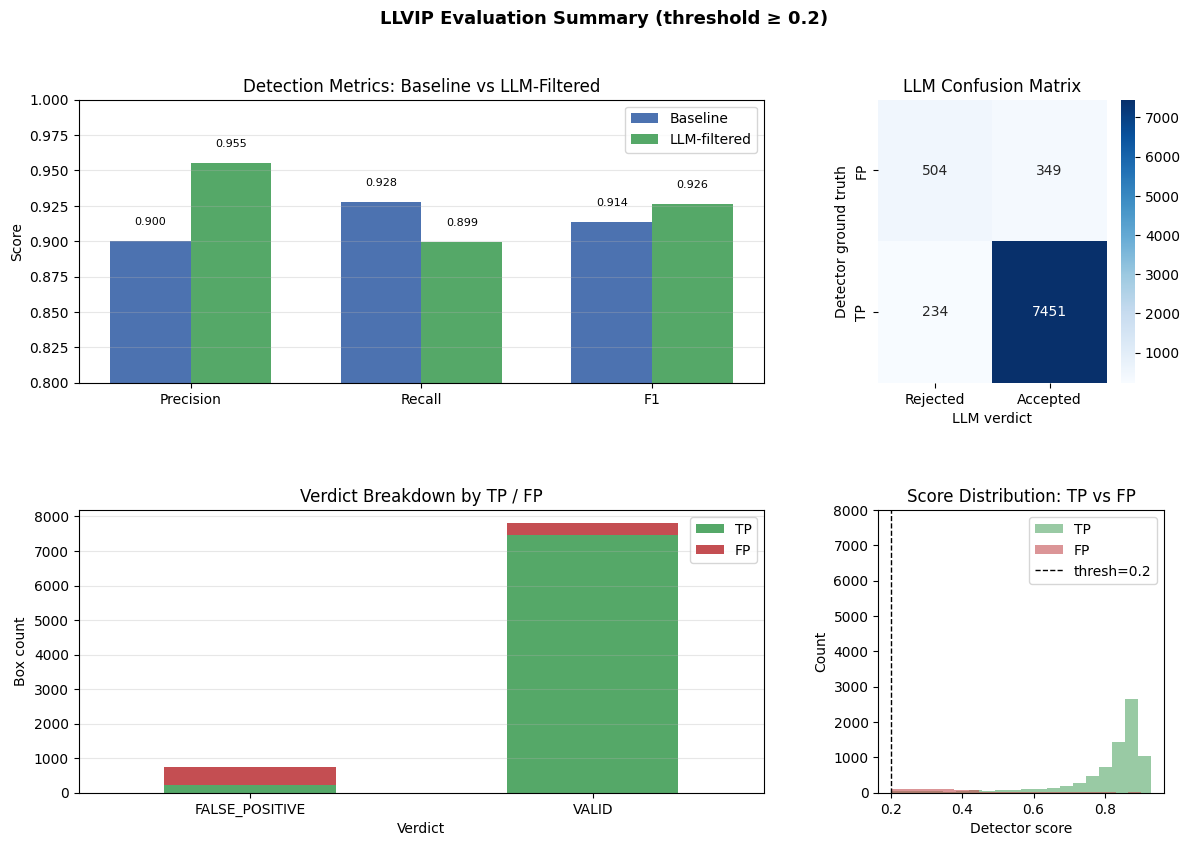

In [ ]:
"""Plot plot plot"""

from sklearn.metrics import precision_recall_fscore_support, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import numpy as np

ACCEPT_VERDICT = "VALID"

def detection_metrics(tp_count: int, fp_count: int, n_gt: int) -> dict[str, float]:
    """Baisc detection metrics"""
    fn        = n_gt - tp_count
    precision = tp_count / (tp_count + fp_count) if (tp_count + fp_count) > 0 else 0.0
    recall    = tp_count / n_gt if n_gt > 0 else 0.0
    f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
    return dict(TP=tp_count, FP=fp_count, FN=fn,
                precision=precision, recall=recall, f1=f1)

base = detection_metrics(
    tp_count = df["is_tp"].sum(),
    fp_count = (~df["is_tp"]).sum(),
    n_gt     = n_gt_total,
)

df_accepted = df[df["verdict"] == ACCEPT_VERDICT]
llm = detection_metrics(
    tp_count = df_accepted["is_tp"].sum(),
    fp_count = (~df_accepted["is_tp"]).sum(),
    n_gt     = n_gt_total,
)

df_judged  = df[df["verdict"] != "MISSING"].copy()
y_true     = df_judged["is_tp"].astype(int)                         # 1=TP, 0=FP
y_pred     = (df_judged["verdict"] == ACCEPT_VERDICT).astype(int)   # 1=accepted

base = precision_recall_fscore_support(y_true, y_pred, average='binary')[0]

cm = confusion_matrix(y_true, y_pred)
report = classification_report(y_true, y_pred,
                                target_names=["FP (not person)", "TP (person)"])

verdict_counts = (df.groupby(["verdict", "is_tp"])
                    .size()
                    .unstack(fill_value=0)
                    .rename(columns={True: "TP", False: "FP"}))

fig = plt.figure(figsize=(14, 9))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.4)

# --- (a) bar: precision / recall / F1 baseline vs filtered ---
ax0 = fig.add_subplot(gs[0, :2])
metrics_labels = ["Precision", "Recall", "F1"]
x = np.arange(len(metrics_labels))
w = 0.35
ax0.bar(x - w/2, [base["precision"], base["recall"], base["f1"]],
        w, label="Baseline", color="#4C72B0")
ax0.bar(x + w/2, [llm["precision"],  llm["recall"],  llm["f1"]],
        w, label="LLM-filtered", color="#55A868")
ax0.set_xticks(x); ax0.set_xticklabels(metrics_labels);
ax0.set_ylim(0.8, 1); ax0.set_ylabel("Score")
ax0.set_title("Detection Metrics: Baseline vs LLM-Filtered")
ax0.legend(); ax0.grid(axis="y", alpha=0.3)
for bar in ax0.patches:
    ax0.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=12)

# --- (b) confusion matrix ---
ax1 = fig.add_subplot(gs[0, 2])
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax1,
            xticklabels=["Rejected", "Accepted"],
            yticklabels=["FP", "TP"])
ax1.set_xlabel("LLM verdict"); ax1.set_ylabel("Detector ground truth")
ax1.set_title("LLM Confusion Matrix")

# --- (c) verdict breakdown stacked bar ---
ax2 = fig.add_subplot(gs[1, :2])
if "TP" not in verdict_counts.columns: verdict_counts["TP"] = 0
if "FP" not in verdict_counts.columns: verdict_counts["FP"] = 0
verdict_counts[["TP","FP"]].plot(
    kind="bar", stacked=True, ax=ax2,
    color=["#55A868","#C44E52"], rot=0)
ax2.set_title("Verdict Breakdown by TP / FP")
ax2.set_xlabel("Verdict"); ax2.set_ylabel("Box count")
ax2.legend(loc="upper right"); ax2.grid(axis="y", alpha=0.3)

# --- (d) score distribution: TP vs FP ---
ax3 = fig.add_subplot(gs[1, 2])
df[df["is_tp"]].score.plot.hist( bins=20, alpha=0.6, ax=ax3, label="TP", color="#55A868")
df[~df["is_tp"]].score.plot.hist(bins=20, alpha=0.6, ax=ax3, label="FP", color="#C44E52")
ax3.axvline(THRESHOLD, color="k", linestyle="--", linewidth=1, label=f"thresh={THRESHOLD}")
ax3.set_xlabel("Detector score"); ax3.set_ylabel("Count")
ax3.set_ylim(0, 8000)
ax3.set_title("Score Distribution: TP vs FP")
ax3.legend()

plt.suptitle(f"LLVIP Evaluation Summary (threshold ≥ {THRESHOLD})", fontsize=13, fontweight="bold")
plt.savefig("eval_summary.png", dpi=150, bbox_inches="tight")
plt.show()